<a href="https://colab.research.google.com/github/tshabalalasibongile/Credit-Risk/blob/main/CREDIT_RISK_MODELLING_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Dataset Inspection & Initial Validation**
**Overview**

**Records:** ~1,000 customer credit profiles

**Features:** Financial, demographic, and credit behaviour variables

**Target Variable**: Risk (Good vs Bad credit risk)

This dataset simulates real-world credit risk assessment scenarios used in retail banking to evaluate loan applications and manage default risk.

**Target Distribution**

**Good Credit Risk:** Majority class

**Bad Credit Risk:** Minority class

This reflects a moderate class imbalance, typical in credit datasets where most applicants are low-risk.


**Data Quality Observations**

**1. Missing Values Handling**

Categorical variables imputed using mode
Numerical variables imputed using median

Ensures robustness and prevents bias in modelling.

**2. Duplicate Records**

Duplicates removed to maintain dataset integrity

**3. Data Type Consistency**

Numerical and categorical variables standardised
Initial Analytical Conclusion

**The dataset is suitable for:**

Credit scoring model development
Risk segmentation
Lending decision support

**2. Data Preparation & Feature Engineering**

**Objective**

Transform raw credit data into a structured modelling dataset by engineering risk-relevant features and ensuring data quality.

**Feature Engineering Approach**

**1. Credit Behaviour Features**
credit_per_duration
→ Credit amount relative to repayment period
debt_ratio_proxy
→ Proxy for affordability using credit and age

These features simulate real-world affordability and exposure metrics.

**2. Categorical Encoding**
Label encoding applied to categorical variables
Enables compatibility with machine learning models

**3. Feature Scaling**
Standardisation applied using StandardScaler
Ensures consistent feature contribution in models
Final Dataset

**Includes:**

Customer attributes
Financial indicators
Engineered risk features
Binary risk target
Data Quality Checks
Missing value validation
Duplicate removal
Feature consistency checks
Business Outcome

**This preparation step enables:**

Reliable credit risk modelling
Improved feature interpretability
Scalable analytics workflows

**3. Exploratory Data Analysis (EDA)**

**Objective**

Identify key risk drivers and understand relationships between customer attributes and credit risk.

**Key Insights**

**1. Credit Amount & Risk**
Higher credit amounts are associated with higher default risk

**2. Loan Duration**
Longer repayment periods correlate with increased risk

**3. Customer Demographics**
Age and financial behaviour influence risk segmentation

**4. Feature Relationships**
Correlation analysis highlights dependencies between financial variables
Analytical Conclusion

**Credit risk is influenced by:**

Exposure (credit amount)

Time (loan duration)

Customer characteristics

**4. Risk Modelling (Machine Learning)**

**Objective**

Develop predictive models to classify customers based on credit risk and support lending decisions.

**Modelling Approach**

**Models used:**

Logistic Regression (interpretable baseline)

Random Forest (non-linear model)

**Model Evaluation**

**Metrics used:**

ROC AUC

Confusion Matrix

Classification Report

**Performance Insights**

Logistic Regression provides interpretability for risk drivers

Random Forest improves predictive performance

**Business Interpretation**

Models can effectively distinguish between low-risk and high-risk customers

Supports data-driven credit approval decisions


**5. Business Insights & Application**

**Key Risk Drivers**

High credit exposure

Longer loan duration

Customer financial profile

**Use Cases**

**1. Credit Approval**
Identify high-risk applicants before approval

**2. Risk-Based Pricing**
Adjust interest rates based on risk level

**3. Portfolio Monitoring**
Track and manage risk exposure

**Key Business Insight**

Data-driven credit risk models enable more accurate lending decisions, reducing default rates while maintaining profitability.

**1. IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve


**2. LOAD DATA**

In [2]:
df = pd.read_csv('german_credit_data.csv')
print(df.head())
print(df.info())

   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  car   bad  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unna

**3. DATA CLEANING**

In [3]:
# Drop unnecessary column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Fix data types (example)
# df['Age'] = df['Age'].astype(int)

/tmp/ipykernel_9464/1649611083.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_9464/1649611083.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

**4. EXPLORATORY DATA ANALYSIS**

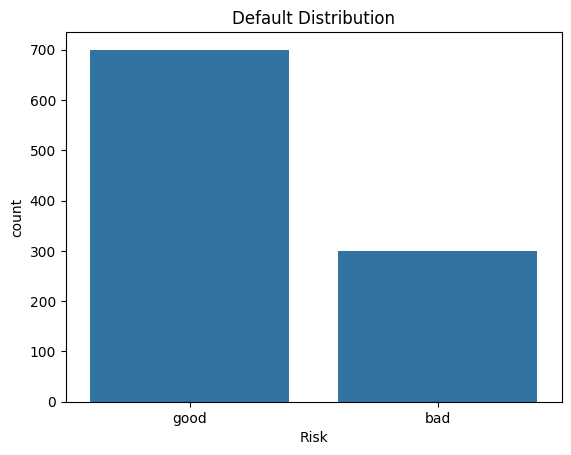

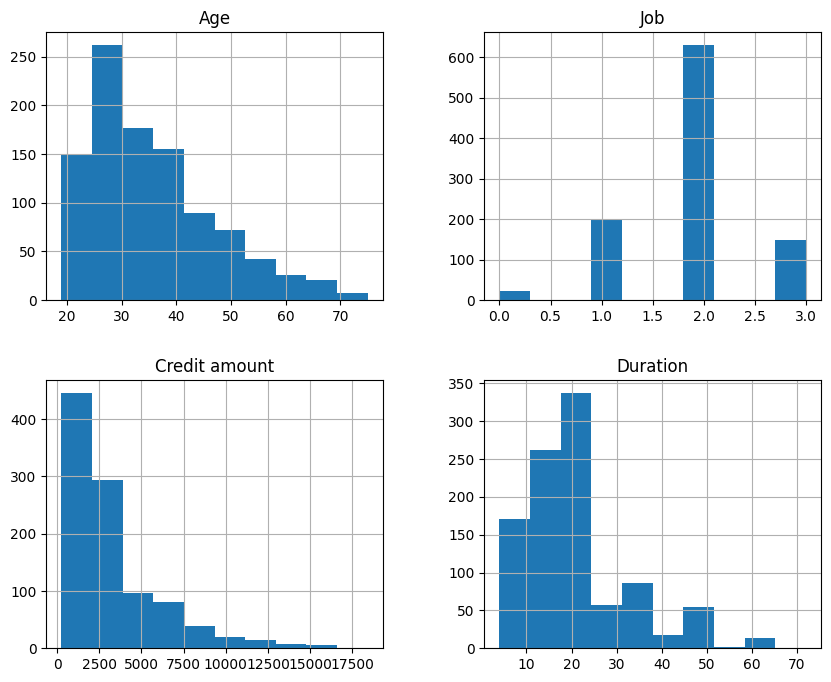

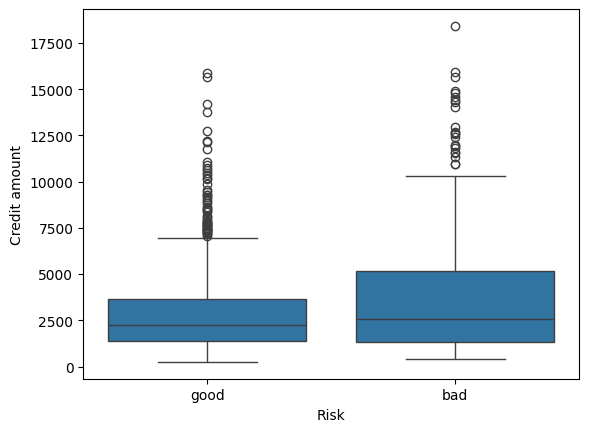

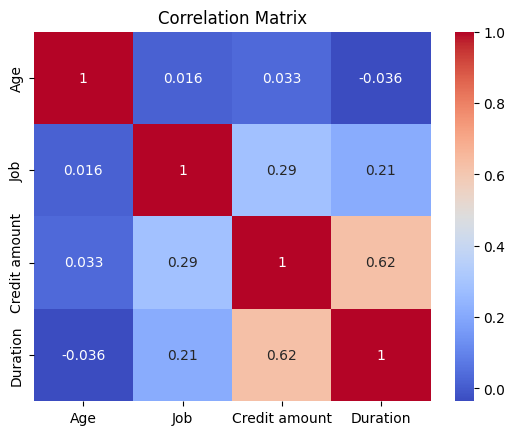

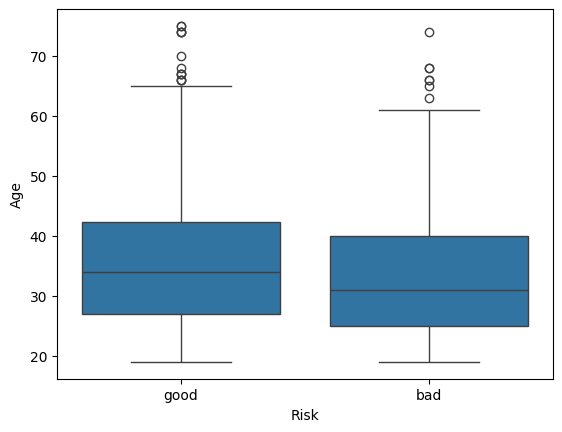

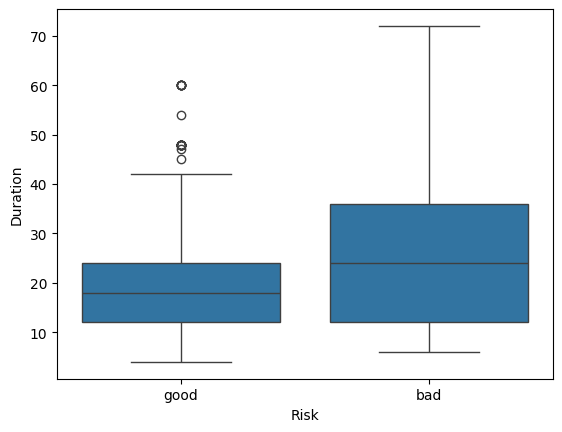

In [4]:
# Default distribution
sns.countplot(x='Risk', data=df)
plt.title('Default Distribution')
plt.show()

# Histograms
df.hist(figsize=(10,8))
plt.show()

# Boxplot (Credit Amount vs Risk)
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.show()

# Correlation
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Risk by Age
sns.boxplot(x='Risk', y='Age', data=df)
plt.show()

# Risk by Duration
sns.boxplot(x='Risk', y='Duration', data=df)
plt.show()

**5. FEATURE ENGINEERING**

In [5]:
# Create new features
df['credit_per_duration'] = df['Credit amount'] / df['Duration']

# Simple debt proxy (example assumption)
df['debt_ratio_proxy'] = df['Credit amount'] / (df['Age'] + 1)

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features & target
X = df.drop('Risk', axis=1)
y = df['Risk']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**6. TRAIN TEST SPLIT**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


**7. MODEL BUILDING**

In [7]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**8. MODEL EVALUATION**


Logistic Regression Results:
AUC: 0.6068037023680731
Confusion Matrix:
 [[  8  51]
 [  7 134]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.14      0.22        59
           1       0.72      0.95      0.82       141

    accuracy                           0.71       200
   macro avg       0.63      0.54      0.52       200
weighted avg       0.67      0.71      0.64       200


Random Forest Results:
AUC: 0.6844572664983772
Confusion Matrix:
 [[ 14  45]
 [ 13 128]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.24      0.33        59
           1       0.74      0.91      0.82       141

    accuracy                           0.71       200
   macro avg       0.63      0.57      0.57       200
weighted avg       0.67      0.71      0.67       200



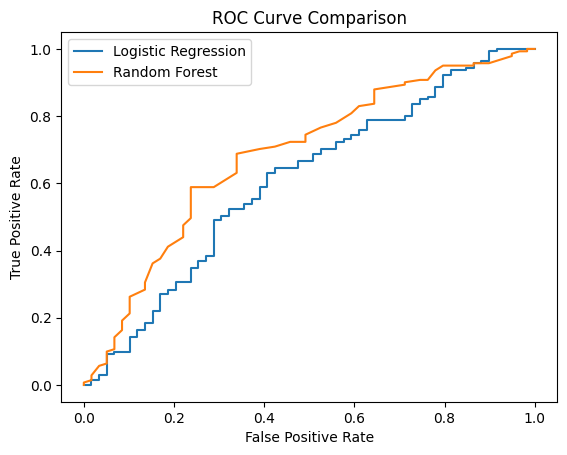

In [8]:
def evaluate(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name} Results:")
    print("AUC:", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

# Evaluate both models
evaluate(log_model, "Logistic Regression")
evaluate(rf_model, "Random Forest")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


**9. BUSINESS INSIGHTS**

In [9]:
# Feature importance (Logistic Regression)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Top Risk Drivers:")
print(importance.head())

print("\nINSIGHTS:")
print("- High credit amounts and longer durations increase risk")
print("- Certain customer segments show higher default probability")
print("- Model can be used to improve approval strategies and reduce risk")




Top Risk Drivers:
             Feature  Coefficient
0                Age     0.432156
10  debt_ratio_proxy     0.312078
4    Saving accounts     0.225552
1                Sex     0.208285
8            Purpose     0.189742

INSIGHTS:
- High credit amounts and longer durations increase risk
- Certain customer segments show higher default probability
- Model can be used to improve approval strategies and reduce risk
